![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


## 🌡️ Tutorial: Heatmaps mit Python (Seaborn)

### 🎯 Ziel:
- Was ist eine Heatmap?
- Wann und warum ist sie nützlich?
- Wie erstellt man Heatmaps mit `seaborn`?
- Was sollte man bei Interpretation und Skalierung beachten?

---

### 📘 Einleitung

> Heatmaps („Wärmebilder“) sind eine der eindrucksvollsten Methoden, um **Zahlen in Farben zu übersetzen**.  
> Sie helfen uns, **Zusammenhänge und Muster auf einen Blick** zu erkennen – ganz ohne aufwändige Statistiken.  
> In diesem Tutorial zeigen wir dir, wie du Heatmaps mit Python und Seaborn erstellst und sinnvoll interpretierst.

---

## 🔧 1. Setup: Bibliotheken & Daten laden

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden
df = sns.load_dataset("penguins")

# Fehlende Werte behandeln (optional)
df = df.dropna()

---

## 🔍 2. Heatmap für Korrelationen erstellen

### ▶️ Ziel: Zeige, wie stark numerische Variablen miteinander zusammenhängen

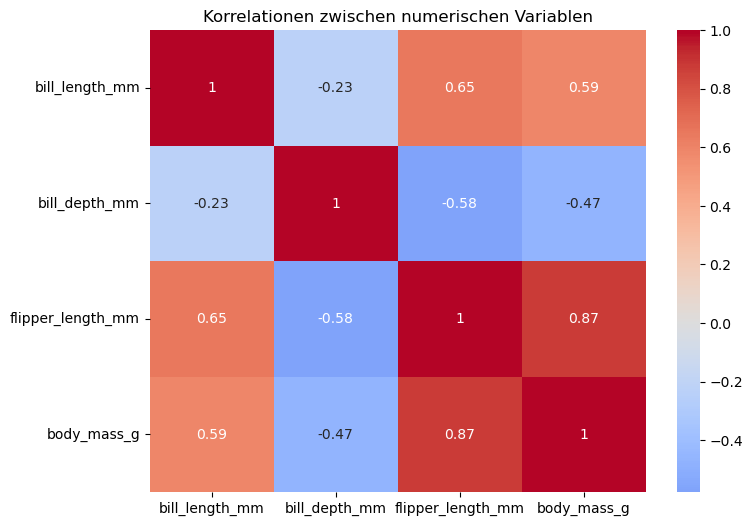

In [5]:
# Korrelation berechnen
corr_matrix = df.corr(numeric_only=True)

# Heatmap anzeigen
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Korrelationen zwischen numerischen Variablen")
plt.show()

---

### 💬 Interpretation:
- `+1.00`: perfekte positive Korrelation (z. B. Flipperlänge & Körpergewicht)
- `-1.00`: perfekte negative Korrelation
- `0.00`: kein linearer Zusammenhang
- Farben helfen, Muster schneller zu erkennen

---

## 🔁 3. Heatmap für gruppierte Mittelwerte

### ▶️ Ziel: Durchschnittliches Körpergewicht je Art & Insel darstellen

In [7]:
pivot_table = df.pivot_table(
    values="body_mass_g", index="species", columns=["island", "sex"], aggfunc="mean"
)

# oder
# Mittelwert pro Art und Insel
grouped = df.groupby(["species", "island"])["body_mass_g"].mean().unstack

In [8]:
display(pivot_table)

island          Biscoe                     Dream                 Torgersen  \
sex             Female         Male       Female         Male       Female   
species                                                                      
Adelie     3369.318182  4050.000000  3344.444444  4045.535714  3395.833333   
Chinstrap          NaN          NaN  3527.205882  3938.970588          NaN   
Gentoo     4679.741379  5484.836066          NaN          NaN          NaN   

island                  
sex               Male  
species                 
Adelie     4034.782609  
Chinstrap          NaN  
Gentoo             NaN

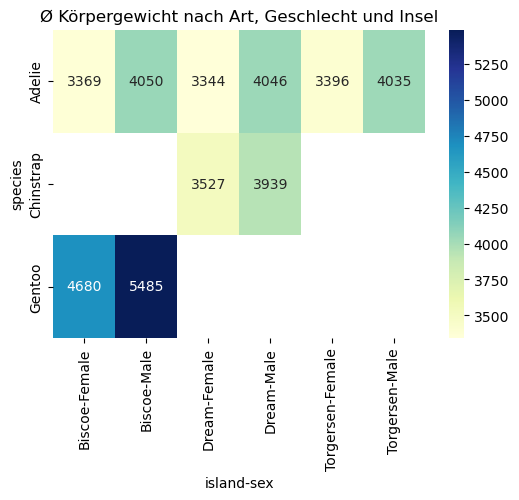

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".0f")
plt.title("Ø Körpergewicht nach Art, Geschlecht und Insel")
plt.show()

## ✅ Fazit

Mit Heatmaps kannst du:
- komplexe Zusammenhänge **visuell aufbereiten**,
- **Gruppenunterschiede** schnell erkennen,
- und Korrelationen auf einen Blick verstehen.
